## Objective:

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("diabetes (1).csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

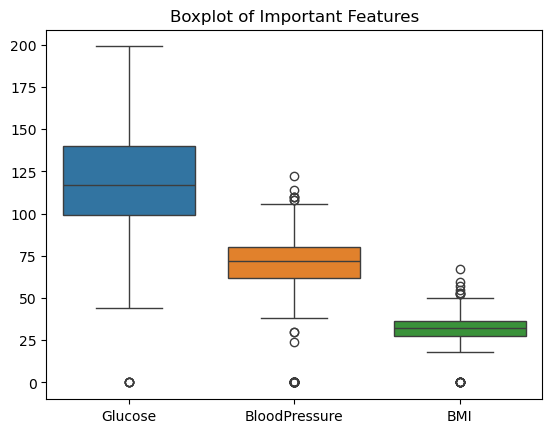

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['Glucose','BloodPressure','BMI']])
plt.title("Boxplot of Important Features")
plt.show()

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("diabetes (1).csv")

# Columns to cap
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping
    df[col] = df[col].clip(lower_bound, upper_bound)

print("Outliers capped successfully!")

Outliers capped successfully!


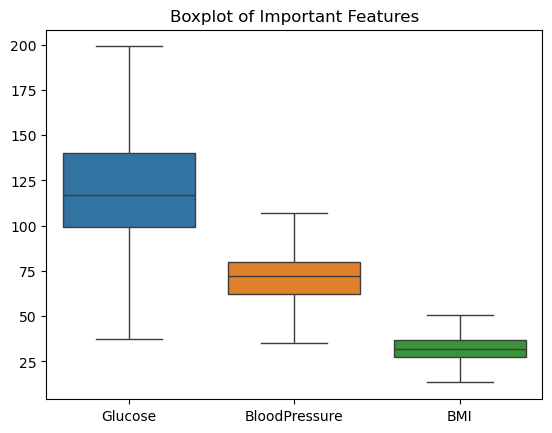

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['Glucose','BloodPressure','BMI']])
plt.title("Boxplot of Important Features")
plt.show()

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

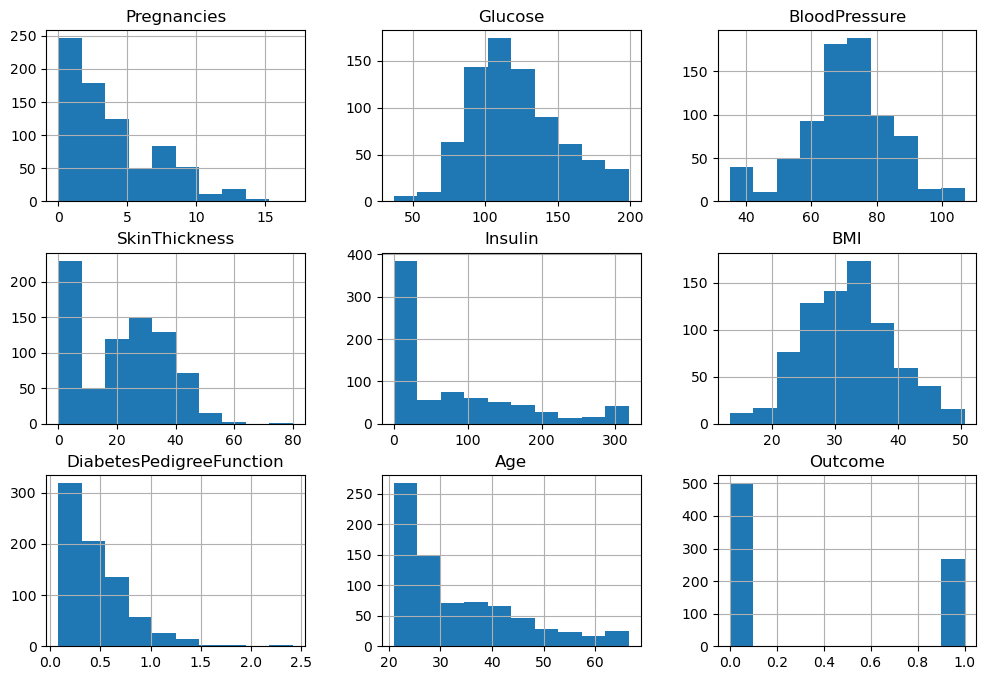

In [6]:
df.hist(figsize=(12,8))

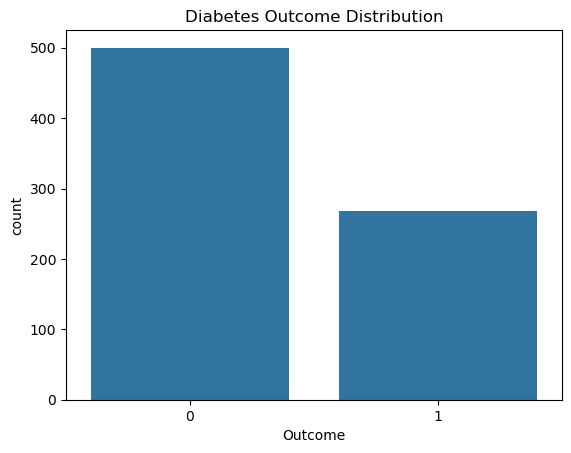

In [7]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

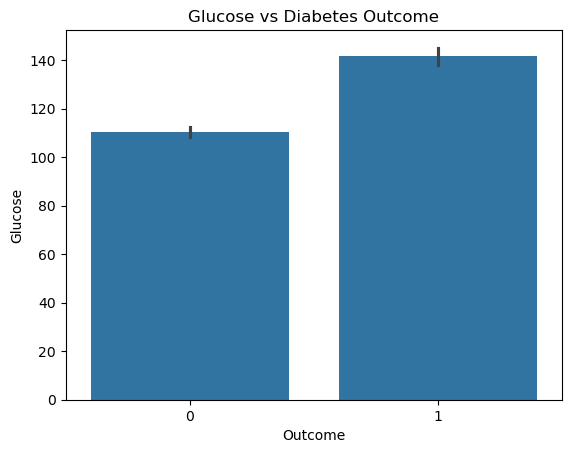

In [8]:
sns.barplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose vs Diabetes Outcome")
plt.show()

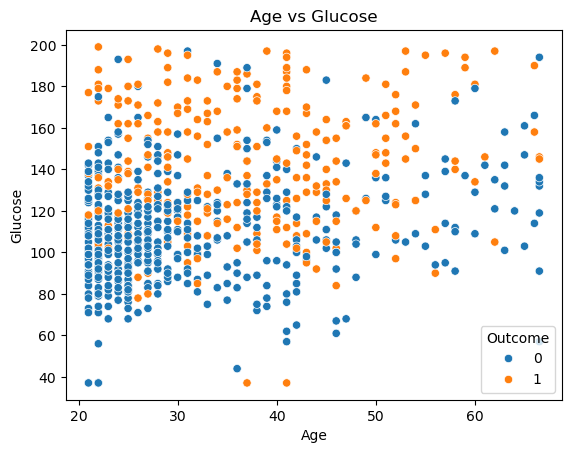

In [9]:
sns.scatterplot(x='Age', y='Glucose', hue='Outcome', data=df)
plt.title("Age vs Glucose")
plt.show()

In [10]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Replace 0 with NaN
df[cols] = df[cols].replace(0, np.nan)

# Fill missing values with median
df.fillna(df.median(), inplace=True)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop('Outcome', axis=1)

X_scaled = scaler.fit_transform(X)

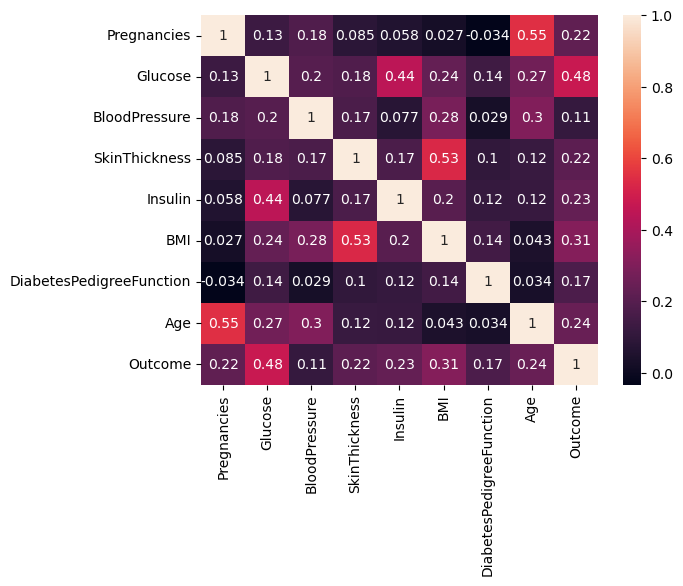

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
#  LightGBM Model
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(verbose=-1)
#
lgbm.fit(X_train, y_train)

#prediction
y_pred_lgbm = lgbm.predict(X_test)
y_pred_lgbm

In [14]:
## XGBoost Model
from xgboost import XGBClassifier

# Initialize model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Train model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb 

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0])

In [15]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,recall_score,f1_score
print("LightGBM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall:", recall_score(y_test, y_pred_lgbm))
print("F1 Score:", f1_score(y_test, y_pred_lgbm))

LightGBM Results:


NameError: name 'y_pred_lgbm' is not defined

In [ ]:
print("\nXGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

In [ ]:
from sklearn.metrics import confusion_matrix

print("LGBM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))
print("XGB Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

In [ ]:
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Models (silent mode)
lgbm = LGBMClassifier(verbose=-1)
xgb = XGBClassifier(eval_metric='logloss', verbosity=0)

# Cross-validation
cv_lgbm = cross_val_score(lgbm, X, y, cv=5, scoring='accuracy')
cv_xgb = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')

print("LGBM CV Accuracy:", cv_lgbm.mean())
print("XGB CV Accuracy:", cv_xgb.mean())

In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

# 🔹 Model with silent mode
lgbm = LGBMClassifier(
    verbose=-1,
    force_col_wise=True   # reduces internal logging
)

# 🔹 Parameter grid
params_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.01, 0.1]
}

# 🔹 Grid Search
grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=params_lgbm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# 🔹 Fit
grid_lgbm.fit(X_train, y_train)

# 🔹 Output
print("Best Parameters (LGBM):", grid_lgbm.best_params_)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(results)

In [ ]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison (LGBM vs XGBoost)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()